# Dependency Risk Multiclass Classification Model

This notebook trains a multiclass classifier for `dependency_level`.

`dependency_level` has three classes:
- low
- medium
- high

This indicator is aligned with KPI logic implemented in `kpi_engine.py`.

Unlike dropout proxy modeling, this target is directly aligned with the business KPI.

Class imbalance exists (high is approximately 5%), so performance for the high class must be interpreted cautiously.

This model is exploratory and MVP-level due to the small sample size (100 records).

## Feature Selection & Leakage Prevention

Target: `dependency_level`.

To avoid leakage, this notebook excludes:

Engineered dependency variables:
- `dependency_risk`
- `dependency_risk_high`

Inverted helper variables:
- `C3_inv`
- `C4_inv`

Raw dependency-defining psychometric items:
- `C1_confio_sin_verificar`
- `C2_dificil_sin_ia`
- `C3_pensamiento_critico`
- `C4_reflexiono_calidad`

Other psychological aggregates:
- `motivation_score`
- `delta_motivation_score`
- `motivation_improved`
- `self_efficacy_score`
- `composite_roi_score`
- `AT_mean`
- `D_mean`
- `E_mean`

Only contextual, demographic, and AI usage variables are used.

In [8]:
# Import only allowed libraries and required sklearn utilities.
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix


def _find_project_root(start_path: str) -> str:
    """Find project root by walking up until .env and backend directory are found."""
    current = os.path.abspath(start_path)
    while True:
        env_candidate = os.path.join(current, '.env')
        backend_candidate = os.path.join(current, 'backend')
        if os.path.isfile(env_candidate) and os.path.isdir(backend_candidate):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise ValueError('Could not locate project root containing .env and backend directory.')


def _read_env_value(env_file: str, key: str) -> str:
    """Read one key from .env file without external dependencies."""
    if not os.path.isfile(env_file):
        return ''
    with open(env_file, 'r', encoding='utf-8') as f:
        for line in f:
            raw = line.strip()
            if not raw or raw.startswith('#') or '=' not in raw:
                continue
            k, v = raw.split('=', 1)
            if k.strip() == key:
                return v.strip().strip('\"').strip("'")
    return ''


# Resolve project root and .env.
project_root = _find_project_root(os.getcwd())
env_path = os.path.join(project_root, '.env')

# Resolve engineered dataset directory from environment with fallback.
engineered_data_dir = os.getenv('ENGINEERED_DATA_DIR') or _read_env_value(env_path, 'ENGINEERED_DATA_DIR') or 'backend/data/processed'
if not os.path.isabs(engineered_data_dir):
    engineered_data_dir = os.path.join(project_root, engineered_data_dir)

# Load engineered dataset.
processed_path = os.path.join(engineered_data_dir, 'survey_engineered.csv')
if not os.path.exists(processed_path):
    raise FileNotFoundError(f'Engineered dataset not found at: {processed_path}')

df = pd.read_csv(processed_path)

# Validate required target exists.
if 'dependency_level' not in df.columns:
    raise ValueError("Required target column 'dependency_level' not found in engineered dataset.")

print(f'Engineered dataset loaded from: {processed_path}')
print(f'Dataset shape: {df.shape}')
print('dependency_level class distribution:')
print(df['dependency_level'].value_counts(dropna=False))

Engineered dataset loaded from: /workspaces/EvaluAI/backend/data/processed/survey_engineered.csv
Dataset shape: (100, 55)
dependency_level class distribution:
dependency_level
medium    64
low       31
high       5
Name: count, dtype: int64


In [9]:
# Define leakage-free structural whitelist (same contextual set as previous clean models).
demographic_features = [
    'edad',
    'antiguedad_empresa',
    'rol_tecnico'
]

ai_usage_features = [
    'frecuencia_uso_ia',
    'usa_chatgpt',
    'usa_gemini',
    'usa_copilot',
    'usa_lms_ia',
    'usa_otra_ia',
    'prefiere_humano_vs_ia',
    'nivel_integracion_ia'
]

categorical_features = [
    'genero',
    'departamento',
    'sector',
    'nivel_educativo',
    'herramienta_principal'
]

required_columns = demographic_features + ai_usage_features + categorical_features + ['dependency_level']
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

# Build feature matrix from leakage-free contextual variables only.
X_raw = df[demographic_features + ai_usage_features + categorical_features].copy()

# Convert numeric whitelisted features and fill missing values.
numeric_whitelist = demographic_features + ai_usage_features
for col in numeric_whitelist:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')
X_raw[numeric_whitelist] = X_raw[numeric_whitelist].fillna(X_raw[numeric_whitelist].median())

# One-hot encode contextual categorical variables with drop_first=True.
X_raw[categorical_features] = X_raw[categorical_features].fillna('Unknown').astype(str)
X = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)

# Encode target labels to integers for sklearn model training.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['dependency_level'].astype(str))

# Print mapping from original labels to encoded integers.
class_mapping = {label: int(idx) for idx, label in enumerate(label_encoder.classes_)}
print('Class mapping (label -> integer):')
print(class_mapping)

print(f'Feature count: {X.shape[1]}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Class mapping (label -> integer):
{'high': 0, 'low': 1, 'medium': 2}
Feature count: 28
X shape: (100, 28)
y shape: (100,)


In [10]:
# Initialize multiclass RandomForest classifier with requested configuration.
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Define reproducible stratified 5-fold split.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define macro metrics to reduce class imbalance bias in evaluation.
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# Run cross-validation and include train scores for overfitting inspection.
cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print('Cross-validation completed successfully.')

Cross-validation completed successfully.


/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classifica

In [11]:
# Build a summary table for test/train metrics and train-test gaps.
metric_names = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
summary_rows = []

for metric in metric_names:
    test_scores = cv_results[f'test_{metric}']
    train_scores = cv_results[f'train_{metric}']

    summary_rows.append({
        'metric': metric,
        'test_mean': float(np.mean(test_scores)),
        'test_std': float(np.std(test_scores)),
        'train_mean': float(np.mean(train_scores)),
        'train_std': float(np.std(train_scores)),
        'train_test_gap': float(np.mean(train_scores) - np.mean(test_scores))
    })

cv_summary = pd.DataFrame(summary_rows)

display_df = cv_summary.copy()
for col in ['test_mean', 'test_std', 'train_mean', 'train_std', 'train_test_gap']:
    display_df[col] = display_df[col].round(4)

print('Cross-validation summary:')
print(display_df.to_string(index=False))

# Macro metrics are preferred because they weight each class equally under imbalance.
print('\nNote: Macro metrics are preferred due to class imbalance.')

Cross-validation summary:
         metric  test_mean  test_std  train_mean  train_std  train_test_gap
       accuracy     0.6300    0.0678      0.9975     0.0050          0.3675
       f1_macro     0.3238    0.0731      0.9980     0.0040          0.6742
precision_macro     0.3157    0.0978      0.9987     0.0026          0.6830
   recall_macro     0.3577    0.0542      0.9973     0.0053          0.6396

Note: Macro metrics are preferred due to class imbalance.


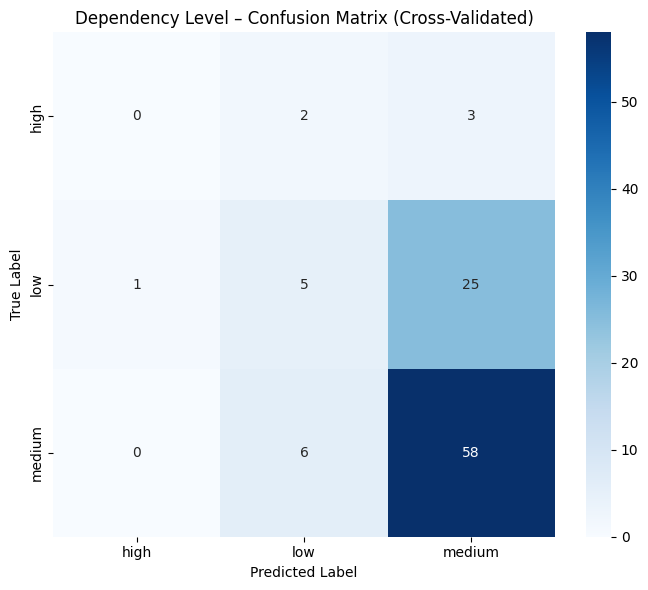

In [12]:
# Generate cross-validated predictions to build confusion matrix.
y_pred_cv = cross_val_predict(rf_model, X, y, cv=cv, n_jobs=-1)

# Compute confusion matrix using encoded labels.
cm = confusion_matrix(y, y_pred_cv)
class_labels = label_encoder.classes_.tolist()

# Plot confusion matrix with seaborn heatmap for easier interpretation.
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Dependency Level – Confusion Matrix (Cross-Validated)')
plt.tight_layout()
plt.show()

Top 10 feature importances:
                    feature  importance
           sector_Servicios    0.111607
                       edad    0.089458
      prefiere_humano_vs_ia    0.089037
         antiguedad_empresa    0.088053
          frecuencia_uso_ia    0.084497
nivel_educativo_FP Superior    0.055753
       nivel_integracion_ia    0.054332
                 usa_gemini    0.043393
               genero_Mujer    0.033461
                usa_otra_ia    0.030638


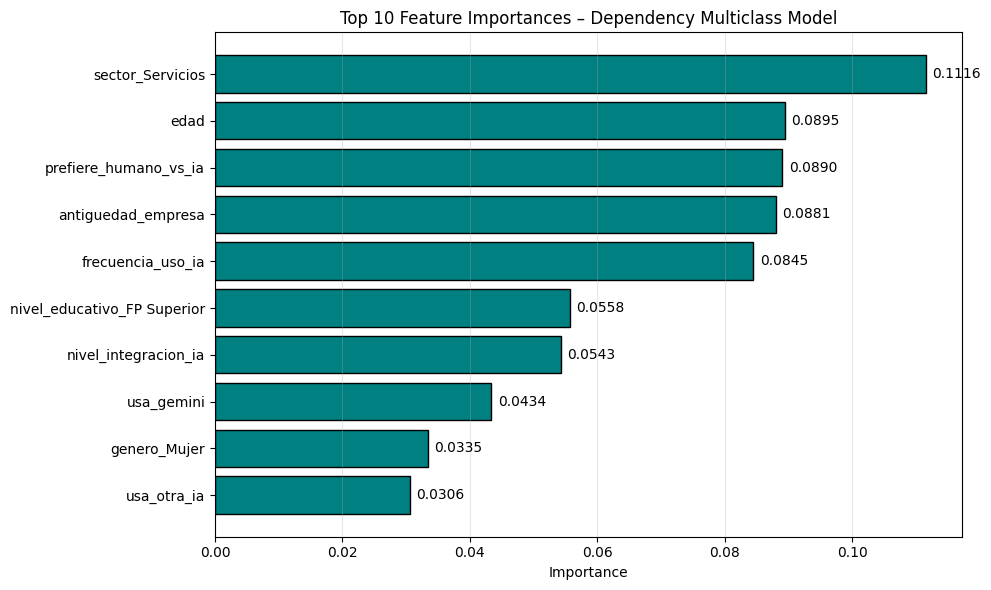

In [13]:
# Train final model on full dataset for deployment artifact.
final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

# Compute feature importances and list top 10.
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_10 = feature_importance_df.head(10).copy()
print('Top 10 feature importances:')
print(top_10.to_string(index=False))

# Plot top 10 feature importances as horizontal bar chart.
plot_top = top_10.sort_values('importance', ascending=True)
plt.figure(figsize=(10, 6))
bars = plt.barh(plot_top['feature'], plot_top['importance'], color='teal', edgecolor='black')
for bar, value in zip(bars, plot_top['importance']):
    plt.text(value + 0.001, bar.get_y() + bar.get_height() / 2, f'{value:.4f}', va='center')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances – Dependency Multiclass Model')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Resolve model output directory from environment/.env with fallback.
model_dir = os.getenv('MODEL_PATH') or _read_env_value(env_path, 'MODEL_PATH') or 'backend/ml/models'
if not os.path.isabs(model_dir):
    model_dir = os.path.join(project_root, model_dir)

os.makedirs(model_dir, exist_ok=True)

# Save trained multiclass model.
model_path = os.path.join(model_dir, 'dependency_multiclass_model.pkl')
joblib.dump(final_model, model_path)

# Build metadata payload with required fields.
class_distribution = df['dependency_level'].value_counts(dropna=False).to_dict()
class_distribution = {str(k): int(v) for k, v in class_distribution.items()}

cv_mean_metrics = {
    row['metric']: float(row['test_mean'])
    for _, row in cv_summary.iterrows()
}

metadata = {
    'model_type': 'RandomForestClassifier',
    'parameters': {
        'n_estimators': 300,
        'max_depth': 8,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'class_weight': 'balanced',
        'random_state': 42
    },
    'n_features': int(X.shape[1]),
    'feature_names': X.columns.tolist(),
    'target': 'dependency_level',
    'class_mapping': class_mapping,
    'class_distribution': class_distribution,
    'cross_validation_metrics': {
        'accuracy': cv_mean_metrics.get('accuracy'),
        'f1_macro': cv_mean_metrics.get('f1_macro'),
        'precision_macro': cv_mean_metrics.get('precision_macro'),
        'recall_macro': cv_mean_metrics.get('recall_macro')
    },
    'note': 'Leakage-free multiclass model',
    'timestamp': pd.Timestamp.utcnow().isoformat()
}

metadata_path = os.path.join(model_dir, 'dependency_multiclass_model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f'Model saved to: {model_path}')
print(f'Metadata saved to: {metadata_path}')

Model saved to: /workspaces/EvaluAI/backend/ml/models/dependency_multiclass_model.pkl
Metadata saved to: /workspaces/EvaluAI/backend/ml/models/dependency_multiclass_model_metadata.json


## Final Interpretation & Business Meaning

### Interpretation of Metrics

- **Accuracy**: overall correctness, but can be misleading under class imbalance.
- **F1_macro**: gives equal weight to each class and is the most informative metric here.
- **Precision_macro** and **Recall_macro**: show class-level balance and detection trade-offs.

### Limitations

- The high-risk class (~5%) is very small, so recall for this class is expected to be low.
- With only 100 samples, estimate stability is limited.

### Business Interpretation

- If macro F1 is above 0.5, the model shows moderate signal.
- Feature importance can highlight structural drivers of AI dependency risk.
- Outputs are useful for dashboard segmentation and adaptive chatbot behavior.

This model predicts dependency level from contextual signals,
not from the psychometric items that define the KPI itself.